In [1]:
# find the gpu devices
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

# in order import from parent directory
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import torch
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np
from custom_vision_transformer import custom_vit_s_16, custom_vit_t_16
from model_training_code.training_utils import get_data_loaders, val_one_epoch
from model_analysis_code.utils import convert_qkv_to_q_k_v

In [3]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=16,
    checkpoint_path="/home/cherr-24/projets/attention-with-bias/training_checkpoints/checkpoint12/vit_custom_epoch_300.pth",
    use_bias=True,
    bias_only=None,
    bias_topk=None,
    bias_score_threshold=None,
)

In [4]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3
Device: cuda:1 NVIDIA GeForce RTX 2080 Ti


In [5]:
model = custom_vit_t_16(num_classes=params.num_classes, image_size=params.img_size, use_bias=params.use_bias, bias_only=params.bias_only, bias_topk=params.bias_topk, bias_score_threshold=params.bias_score_threshold).to(device)
checkpoint = torch.load(params.checkpoint_path, map_location=device)
checkpoint = checkpoint["model_state_dict"]
checkpoint = convert_qkv_to_q_k_v(checkpoint)
model.load_state_dict(checkpoint)
model.eval();

/tmp/ipykernel_1094819/439172363.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(params.checkpoint_path, map_location=device)


In [6]:
_, val_loader, _, _ = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

In [7]:
avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
print(f"Validation Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

Validation Accuracy: 0.7840, Top-5 Accuracy: 0.9282, Average Pruning Ratio: 0.0000


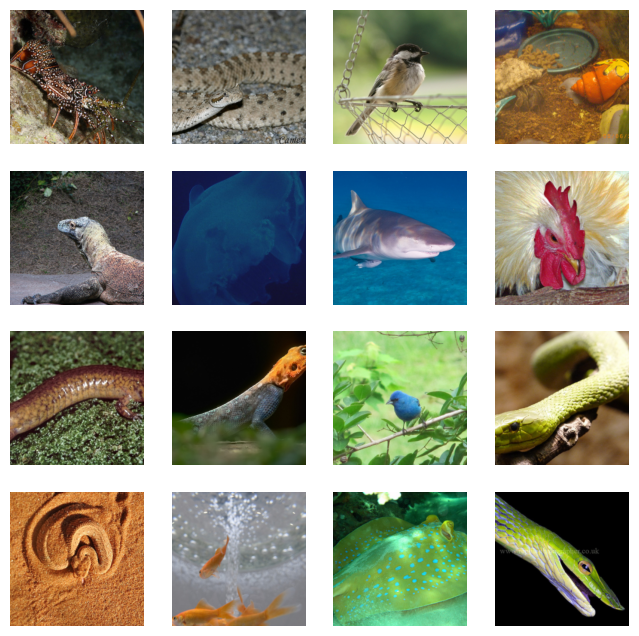

In [8]:
# display some images
imgs, labels = next(iter(val_loader))

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
sample_imgs = imgs[:16]  # take first 16 images
sample_imgs = sample_imgs.cpu().permute(0, 2, 3, 1) * torch.tensor(std).view(1, 1, 1, 3) + torch.tensor(mean).view(1, 1, 1, 3)
sample_imgs = torch.clamp(sample_imgs, 0, 1).numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
plt.show()

In [9]:
# Nettoyer les anciens hooks
for _, module in model.named_modules():
    if hasattr(module, '_forward_hooks'):
        module._forward_hooks.clear()

# Setup: créer les hooks pour extraire Q, K, QK, b
qk_by_layer = {}
b_by_layer = {}

def make_qk_b_hook(name):
    def hook(module, input, output):
        x = input[0]  # [B, T, C]
        B, T, _ = x.shape
        H, D = module.num_heads, module.head_dim

        # Extraire Q, K du qkv projection
        q = module.q(x).reshape(B, T, H, D).transpose(1, 2)  # (B, H, T, D)
        k = module.k(x).reshape(B, T, H, D).transpose(1, 2)  # (B, H, T, D)

        # Calculer QK logits
        qk = (q @ k.transpose(-2, -1)) * module.scale  # [B, H, T, T]
        qk_by_layer[name] = qk.cpu()

        # Extraire le biais b (si defini)
        if module.b is not None:
            b = module.b(x)  # [B, T, H]
            b = b.permute(0, 2, 1)  # [B, H, T]
            b_by_layer[name] = b.cpu()
        else:
            b_by_layer[name] = torch.zeros(B, H, T)
    return hook

# Enregistrer les hooks sur tous les modules .self_attention
layer_names = []
for name, module in model.named_modules():
    if name.endswith(".self_attention"):
        module.register_forward_hook(make_qk_b_hook(name))
        layer_names.append(name)


# take a single image and run it through the model to fill the dictionaries
tensor = imgs[0].unsqueeze(0).to(device)

with torch.no_grad():
    _ = model(tensor)

In [10]:
# Visualiser: QK, b, QK+b, softmax(QK+b), softmax(b)

output_dir = "../results/attention_maps"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, layer_name in enumerate(layer_names):
    qk = qk_by_layer[layer_name][0]
    b = b_by_layer[layer_name][0]
    n_heads = qk.shape[0]

    fig, axes = plt.subplots(5, n_heads, figsize=(18, 15))
    fig.suptitle(f"Layer {layer_idx}", fontsize=20)

    for head in range(n_heads):
        qk_h = qk[head]
        b_h_map = b[head].unsqueeze(0).repeat(qk_h.shape[0], 1)
        sum_map = qk_h + b_h_map

        amp = max(qk_h.abs().max().item(), b_h_map.abs().max().item(), sum_map.abs().max().item()) + 1e-12
        vmin, vmax = -amp, amp

        for ax, data, label in [(axes[0, head], qk_h, f"QK head{head}"), (axes[1, head], b_h_map, f"b head{head}"), (axes[2, head], sum_map, f"QK+b head{head}")]:
            ax.imshow(data.numpy(), cmap="RdBu_r", vmin=vmin, vmax=vmax)
            dmin, dmax = data.min().item(), data.max().item()
            ax.set_title(f"{label}\namp={amp:.2f} [{dmin:.2f},{dmax:.2f}]", fontsize=9)
            ax.axis("off")

        attn_with_b = torch.softmax(sum_map, dim=-1)
        axes[3, head].imshow(attn_with_b.numpy(), cmap="viridis", vmin=0.0, vmax=attn_with_b.max().item())
        axes[3, head].set_title(f"softmax(QK+b) head{head}\nmax={attn_with_b.max().item():.3f}", fontsize=9)
        axes[3, head].axis("off")

        attn_b = torch.softmax(b_h_map, dim=-1)
        axes[4, head].imshow(attn_b.numpy(), cmap="viridis", vmin=0.0, vmax=attn_b.max().item())
        axes[4, head].set_title(f"softmax(b) head{head}\nmax={attn_b.max().item():.3f}", fontsize=9)
        axes[4, head].axis("off")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_qk_b_qkplusb_with_softmax.png")
    plt.close(fig)

In [11]:
# Scatter plots: b vs mean(QK), b vs mean(QK+b)

output_dir = "../results/scatter_plots"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, layer_name in enumerate(layer_names):
    qk = qk_by_layer[layer_name][0]
    b = b_by_layer[layer_name][0]
    n_heads = qk.shape[0]

    fig, axes = plt.subplots(2, n_heads, figsize=(18, 15))
    fig.suptitle(f"Layer {layer_idx}", fontsize=20)

    for head in range(n_heads):
        qk_h = qk[head]
        b_h = b[head]
        sum_map = qk_h + b_h.unsqueeze(0)

        qk_mean = qk_h.mean(dim=0).numpy()
        sum_mean = sum_map.mean(dim=0).numpy()

        b_np = b_h.numpy()
        c1, c2 = np.corrcoef(b_np, qk_mean)[0, 1], np.corrcoef(b_np, sum_mean)[0, 1]

        # Ligne 1: b vs mean(QK)
        axes[0, head].scatter(b_np, qk_mean, s=12, alpha=0.8)
        axes[0, head].set_title(f"head{head} QK (r={c1:.2f})", fontsize=9)
        axes[0, head].grid(True, alpha=0.3)
        axes[0, head].set_xlabel("b")
        axes[0, head].set_ylabel("mean(QK)")

        # Ligne 2: b vs mean(QK+b)
        axes[1, head].scatter(b_np, sum_mean, s=12, alpha=0.8)
        axes[1, head].set_title(f"head{head} QK+b (r={c2:.2f})", fontsize=9)
        axes[1, head].grid(True, alpha=0.3)
        axes[1, head].set_xlabel("b")
        axes[1, head].set_ylabel("mean(QK+b)")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_scatter_b_qk.png")
    plt.close(fig)

In [12]:
# Afficher la distribution des biais pour chaque head de chaque layer et l'entropie normalisée associée

output_dir = "../results/bias_distributions"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, layer_name in enumerate(layer_names):
    b = b_by_layer[layer_name][0].detach().cpu()
    n_heads = b.shape[0]

    fig, axes = plt.subplots(1, n_heads, figsize=(24, 5), squeeze=False)
    fig.suptitle(f"Bias distribution - Layer {layer_idx}", fontsize=13)
    axes = axes[0]

    for head in range(n_heads):
        values = b[head].numpy()
        probs = torch.softmax(b[head], dim=-1)
        entropy = -(probs * torch.log(probs + 1e-9)).sum().item()
        normalized_entropy = entropy / torch.log(torch.tensor(b.shape[1], dtype=torch.float)).item()

        axes[head].hist(values, bins=30, color="steelblue", edgecolor="black", linewidth=0.3)
        axes[head].set_title(f"Head {head} (Normalized Entropy: {normalized_entropy:.2f})", fontsize=10)
        axes[head].set_xlabel("Bias")
        axes[head].set_ylabel("Number of tokens")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/bias_distribution_layer_{layer_idx:02d}.png", bbox_inches="tight")
    plt.close(fig)

In [13]:
# Visualiser le nombre de tokens prunes par layer et par head

method = "bias_topk" if params.bias_topk is not None else "bias_score_threshold" if params.bias_score_threshold is not None else "no pruning"

def get_attention_pruning_metrics_per_layer(model):
    base_model = model._orig_mod if hasattr(model, "_orig_mod") else model

    pruned_ratios = []
    for module in base_model.modules():
        if hasattr(module, "last_pruned_ratio"):
            pruned_ratios.append(module.last_pruned_ratio.detach().tolist())

    return pruned_ratios


with torch.no_grad():
    # take a batch of images and run it through the model to fill the pruning metrics
    imgs, labels = next(iter(val_loader))
    output = model(imgs.to(device))
    pruned_ratios_per_layer = get_attention_pruning_metrics_per_layer(model)

for i, ratio in enumerate(pruned_ratios_per_layer):
    print(f"Layer {i}: Average Pruning Ratio = {ratio}")

# Visualiser le nombre de tokens prunes par layer
plt.figure(figsize=(8, 4))
plt.plot(range(len(pruned_ratios_per_layer)), pruned_ratios_per_layer, marker='o')
plt.title(f"Average Pruning Ratio per Layer ({method})", fontsize=14)
plt.xlabel("Layer Index", fontsize=12)
plt.ylabel("Average Pruning Ratio", fontsize=12)
plt.xticks(range(len(pruned_ratios_per_layer)))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"../results/pruned_ratios_per_layer_{method}.png")
plt.close()


Layer 0: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 1: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 2: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 3: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 4: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 5: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 6: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 7: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 8: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 9: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 10: Average Pruning Ratio = [0.0, 0.0, 0.0]
Layer 11: Average Pruning Ratio = [0.0, 0.0, 0.0]


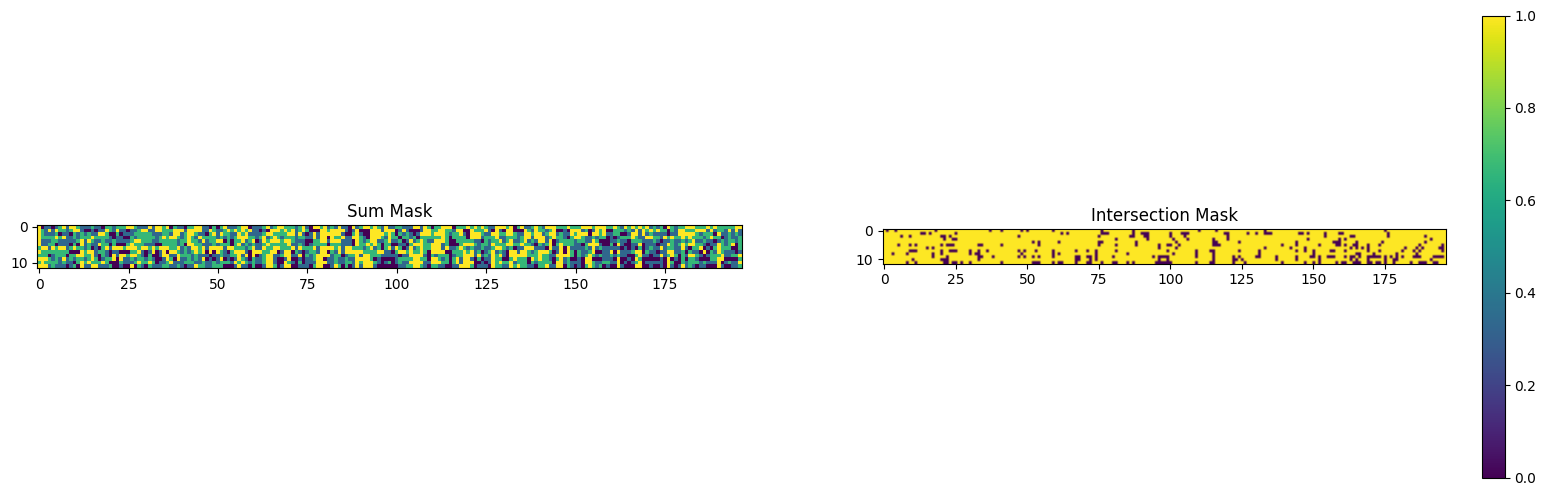

In [17]:
# Carte des tokens masqués pour chaque layer

bias_score_threshold = 0.8

sum_mask_list = []
intersection_mask_list = []

for name, b in b_by_layer.items():
    b = b[0]  # (H, T)
    bias_score = torch.softmax(b, dim=-1)  # (H, T)
    sorted_scores, sorted_indices = torch.sort(bias_score, dim=-1, descending=True)  # (H, T)
    cumsum_scores = torch.cumsum(sorted_scores, dim=-1)  # (H, T)
    mask_sorted = (cumsum_scores <= bias_score_threshold)  # (H, T)
    mask = torch.zeros_like(b, dtype=torch.bool).scatter_(-1, sorted_indices, mask_sorted)  # (H, T)

    sum_mask = mask.sum(dim=0).unsqueeze(0)  # (1, T)
    intersection_mask = mask.any(dim=0).unsqueeze(0)  # (1, T)
    sum_mask_list.append(sum_mask)
    intersection_mask_list.append(intersection_mask)

concatenated_sum_mask = torch.cat(sum_mask_list)  # (num_layers, T)
concat_intersection_mask = torch.cat(intersection_mask_list) # (num_layers, T)

plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.imshow(concatenated_sum_mask.numpy())
plt.title("Sum Mask")
plt.subplot(1, 2, 2)
plt.imshow(concat_intersection_mask.numpy())
plt.title("Intersection Mask")
plt.colorbar()
plt.show()

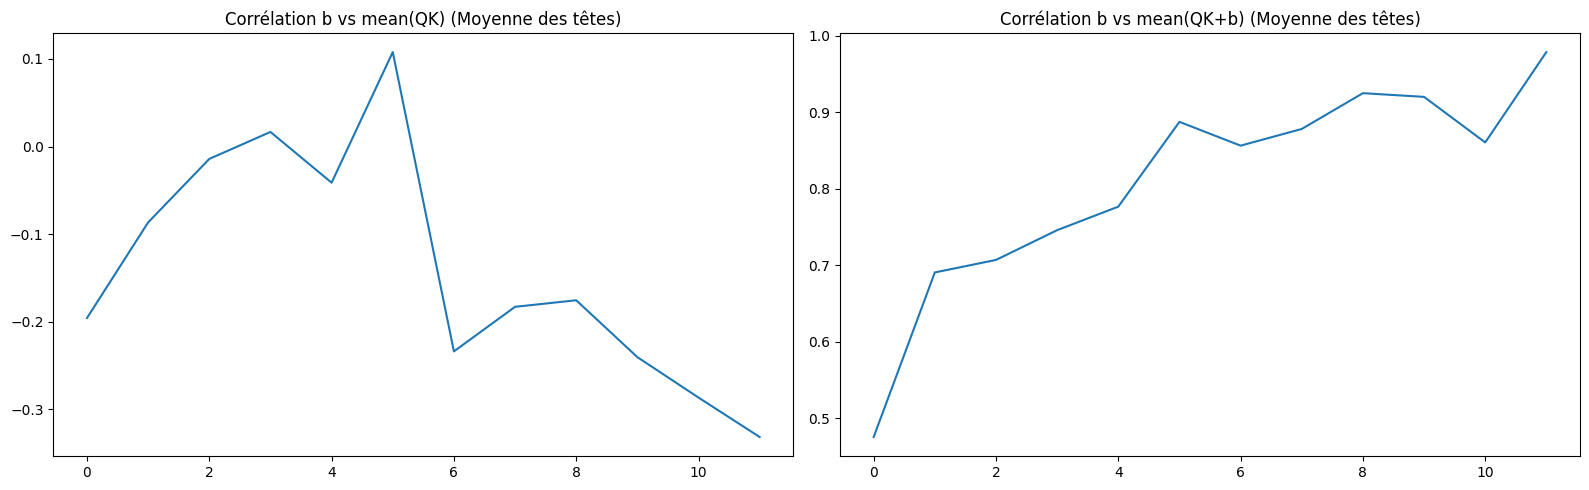

In [18]:
# calculer correlation b et mean(QK) et b et mean(QK+b) à travers les couches

def batch_correlation(X, Y):
    X_centered = X - X.mean(dim=1, keepdim=True)
    Y_centered = Y - Y.mean(dim=1, keepdim=True)
    corr = torch.cosine_similarity(X_centered, Y_centered, dim=1)
    return corr.mean().item()


imgs, labels = next(iter(val_loader))

with torch.no_grad():
    _ = model(imgs.to(device))


# Listes pour stocker les scores par couche : [ [head1, head2, ...], [head1, head2, ...], ... ]
corr_c1_layers = []
corr_c2_layers = []

for layer_idx, layer_name in enumerate(layer_names):
    qk = qk_by_layer[layer_name].cpu()
    b = b_by_layer[layer_name].cpu()
    n_heads = qk.shape[1]

    c1_heads = []
    c2_heads = []

    for head in range(n_heads):
        qk_h = qk[:, head]  
        b_h = b[:, head]    
        sum_map = qk_h + b_h.unsqueeze(-2)

        qk_mean = qk_h.mean(dim=1)   
        sum_mean = sum_map.mean(dim=1) 

        # Calcul des corrélations
        c1 = batch_correlation(b_h, qk_mean)
        c2 = batch_correlation(b_h, sum_mean)

        c1_heads.append(c1)
        c2_heads.append(c2)
    
    # On stocke les résultats de toutes les têtes de la couche actuelle
    corr_c1_layers.append(c1_heads)
    corr_c2_layers.append(c2_heads)

# --- Calcul des moyennes selon les têtes ---
# En convertissant en array numpy (Shape: Nb_couches, Nb_têtes), 
# on fait la moyenne sur l'axe 1 (les têtes) pour obtenir un score par couche.
mean_c1_per_layer = np.mean(corr_c1_layers, axis=1)
mean_c2_per_layer = np.mean(corr_c2_layers, axis=1)

# --- Affichage graphique ---
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.plot(mean_c1_per_layer)
plt.title("Corrélation b vs mean(QK) (Moyenne des têtes)")
plt.subplot(1, 2, 2)
plt.plot(mean_c2_per_layer)
plt.title("Corrélation b vs mean(QK+b) (Moyenne des têtes)")
plt.tight_layout()
plt.show()